# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [20]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("easonlai/sample-insurance-claim-prediction-dataset")

print("Path to dataset files:", path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv(f'{path}/insurance2.csv')

Path to dataset files: /Users/chenglong/.cache/kagglehub/datasets/easonlai/sample-insurance-claim-prediction-dataset/versions/2


In [21]:
medical.shape

(1338, 8)

In [22]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

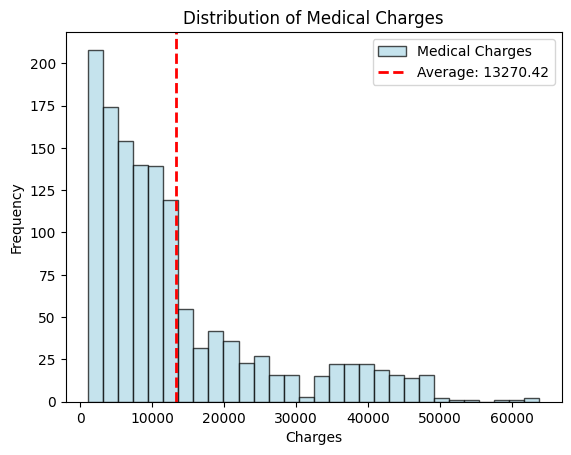

Average: 13270.42, Standard Deviation: 12110.01


In [23]:
plt.hist(medical['charges'], bins=30, edgecolor='black',color='lightblue', alpha=0.7, label='Medical Charges')
plt.axvline(avg, color='red', linestyle='--', linewidth=2, label=f'Average: {avg:.2f}')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')
plt.legend()
plt.show()
avg = np.mean(medical['charges'])  
stddev = np.std(medical['charges'], ddof=1)
print(f"Average: {avg:.2f}, Standard Deviation: {stddev:.2f}")



The standard deviation is almost as large as the mean, insurance charges likely have a wide spread and may be right-skewed, with some individuals having much higher charges than others. In this situation, the mean and standard deviation may not fully represent the typical insurance charge. The median and IQR would also be appropriate statistics to report because they are less affected by extreme values.

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__

Assuming the data represent a random sample of insurance charges, they can be used to make inferences about the population mean charge. Since the administrator is concerned specifically that the population mean has fallen below $12,000, the appropriate test is a one-sample, left-tailed t-test. The null hypothesis is \(H_0:\mu=12,000\), and the alternative hypothesis is \(H_A:\mu<12,000\). The t-test is appropriate because the population standard deviation is unknown and must be estimated using the sample standard deviation.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__

In [24]:
len(medical['charges'])
n = 1338
mean = 13270.42
sd = 12110.01

# Degrees of freedom
df = n - 1

# 95% one-sided critical value
t_critical = t.ppf(0.95, df)

# Standard error
se = sd / np.sqrt(n)

# Lower confidence bound
lower = mean - t_critical * se

print("Degrees of freedom:", df)
print("Critical value:", t_critical)
print("Standard error:", se)
print("Lower confidence bound:", lower)
print("95% one-sided CI:", (lower, np.inf))

Degrees of freedom: 1337
Critical value: 1.6459941145571317
Standard error: 331.06742050653673
Lower confidence bound: 12725.48497432463
95% one-sided CI: (np.float64(12725.48497432463), inf)


No. Based on the 95% one-sided confidence interval, the administrator should not be concerned based on these data.

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__

The null hypothesis is \(H_0:\mu_0-\mu_1=0\), meaning that the mean charges are the same for people with and without insurance. The alternative hypothesis is \(H_A:\mu_0-\mu_1\neq0\), meaning that the mean charges differ between the two groups. Because we are using the pooled standard deviation, we are assuming that the two groups have equal population variances, \(\sigma_0^2=\sigma_1^2\).

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [25]:

group0 = medical[medical['insuranceclaim'] == 0]['charges']
group1 = medical[medical['insuranceclaim'] == 1]['charges']

n0 = len(group0)
n1 = len(group1)

xbar0 = group0.mean()
xbar1 = group1.mean()

s0 = group0.std()
s1 = group1.std()

sp = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
t_stat = (xbar0 - xbar1) / (sp * np.sqrt(1/n0 + 1/n1))
df = n0 + n1 - 2
p_value = 2 * t.cdf(-abs(t_stat), df)

print("n0:", n0)
print("n1:", n1)
print("Mean group 0:", xbar0)
print("Mean group 1:", xbar1)
print("Pooled SD:", sp)
print("t-statistic:", t_stat)
print("p-value:", p_value)

n0: 555
n1: 783
Mean group 0: 8821.421892306305
Mean group 1: 16423.928276537677
Pooled SD: 11520.034268775256
t-statistic: -11.893299030876715
p-value: 4.4612302316205886e-31


In [26]:
from scipy.stats import ttest_ind

test = ttest_ind(group0, group1, equal_var=True)

print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)

t-statistic: -11.893299030876712
p-value: 4.461230231620717e-31


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__

There is no direct z-test function in scipy.stats equivalent to the t-test functions. This is because z-tests generally require the population standard deviation to be known, whereas t-tests are used when the population standard deviation is unknown and must be estimated from the sample. A z-test can still be performed manually using the standard normal distribution, such as with scipy.stats.norm.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test